In [2]:
import matplotlib.pyplot as plt   # to plot signals
import numpy as np

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv


In [4]:
import pandas as pd

csv_path = "/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (8732, 8)
Columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


### **Basic dataset Info**

**How big is it? What’s the class balance?**

In [5]:
# Check folds
print("\nFolds distribution:\n", df['fold'].value_counts())


Folds distribution:
 fold
4     990
5     936
3     925
2     888
1     873
7     838
10    837
6     823
9     816
8     806
Name: count, dtype: int64


In [6]:
df['duration'] = df['end'] - df['start']

df['duration'].describe()

count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: duration, dtype: float64

In [7]:
df['class'].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

### **EDA**

In [8]:
import IPython.display as ipd  # to display audio file

In [9]:
# Correct audio base
audio_base = "/kaggle/input/datasets/chrisfilo/urbansound8k"

# Random sample
row = df.sample(1).iloc[0]

file_path = os.path.join(audio_base, f"fold{row['fold']}", row['slice_file_name'])

print(file_path)
print("Exists:", os.path.exists(file_path))  # MUST be True

/kaggle/input/datasets/chrisfilo/urbansound8k/fold4/132016-7-0-0.wav
Exists: True


In [10]:
print(os.path.exists(file_path))

True


In [11]:
ipd.Audio(file_path)

## 📊**Plot sound wave**

### **Using `librosa`**

#### by default `librosa` 
- #### converts audio into **mono(single) channel = same sound everywhere**
- #### **Resamples** audio to **22050 Hz**
- #### **Normalized, `[-1,1]`**
- #### output: float

In [12]:
import librosa
print(librosa.__version__)

0.11.0


In [13]:
data, sample_rate = librosa.load(file_path)

In [14]:
data  # waveform (array of sound values)

array([ 0.03417049,  0.0515803 ,  0.04596324, ..., -0.04972354,
       -0.03597305, -0.02235061], dtype=float32)

In [15]:
sample_rate

22050

In [16]:
import librosa.display

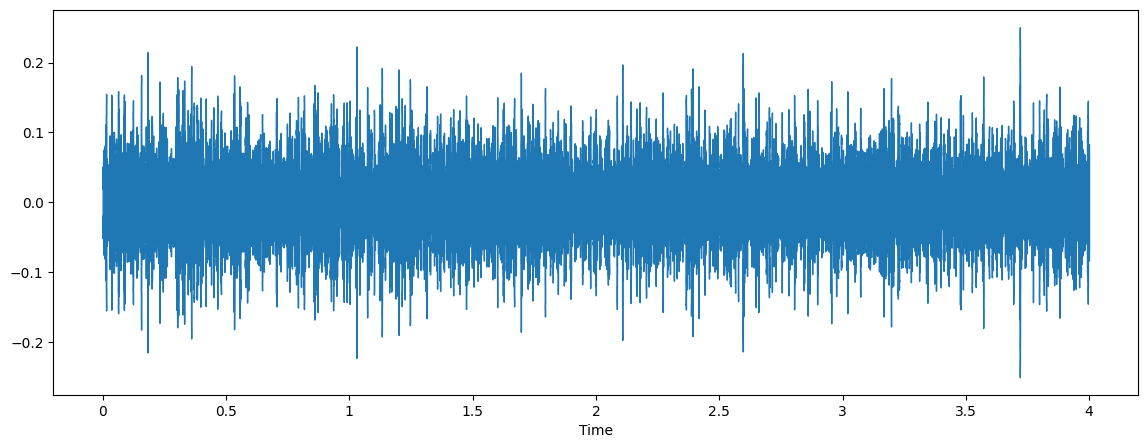

In [17]:
plt.figure(figsize=(14,5))
librosa.display.waveshow(data, sr=sample_rate)

### **Using `scipy`**

#### By default, keep the audio signal **as it is (either mono = 1 or stareo = 2 audio channel)**
- #### No conversion
- #### No resampling
- #### No normalization
#### We get **the raw audio**

In [18]:
from scipy.io import wavfile as wav


In [19]:
audio_sample_rate, audio_data = wav.read(file_path)

In [20]:
audio_data

array([[ 1755,  1214],
       [ 1523,  1622],
       [ 1341,  1825],
       ...,
       [-1007,  -786],
       [ -823,  -582],
       [ -748,  -462]], dtype=int16)

In [21]:
audio_sample_rate

44100

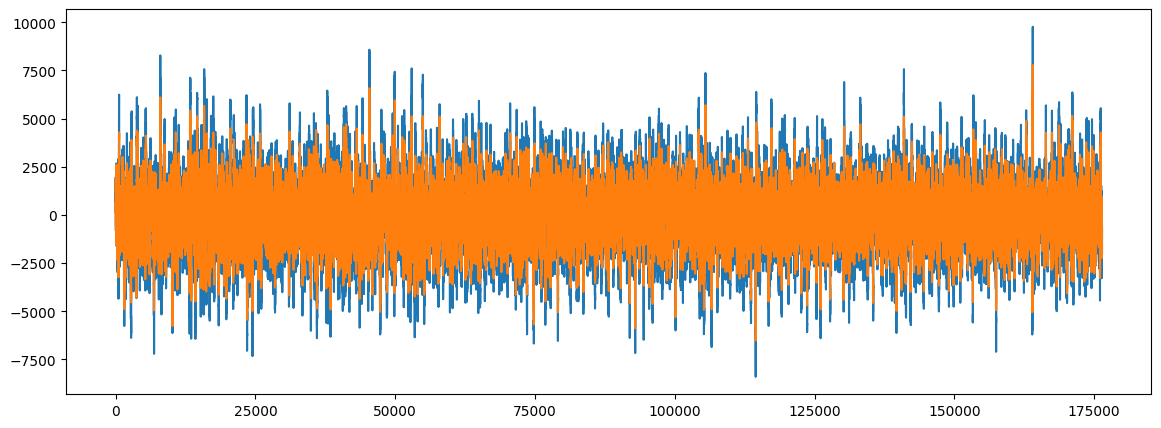

In [22]:
plt.figure(figsize=(14,5))
plt.plot(audio_data)

## **🎧Feature Extraction**

### **MFCC**
- #### converts raw audio into **compact numerical features** that represent sound characteristics
- #### return 2D array (matrix) of MFCC features - **(no. of features, time frame)**
- #### time frame - No. of audio segments
 #### ✔ `n_mfcc=40` → more features = more detail
 #### ✔ `res_type='kaiser_fast'` → faster loading

#### Audio signal 🎧

   ↓
#### Split into small frames (time chunks)

   ↓
#### From each frame → extract 40 MFCC features (characteristics)

In [23]:
# for 1 audio file

def feature_extractor(file):
    data, sample_rate = librosa.load(file, sr=None)  # load audio file
    mfcc_features = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=40) # extract MFCC(40,time_frame)
    mfcc_scaled_features = np.mean(mfcc_features.T,axis=0) # transpose(time_frame,40) & avg over time
  
    return mfcc_scaled_features  # return 1D fixed-size vector/ converts variable-length audio -> fixed-size vector

In [24]:
mfcc_features = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=40) # extract MFCC(40,time_frame)
mfcc_features.shape

(40, 173)

In [25]:
mfcc_features.T.shape

(173, 40)

In [26]:
mfcc_scaled_features = np.mean(mfcc_features.T,axis=0)
mfcc_scaled_features.shape

(40,)

In [27]:

from tqdm import tqdm
# Now we iterate through every audio file & extract features using MFCC
extracted_features=[]

for index, row in tqdm(df.iterrows()):
    file_name = os.path.join(audio_base, "fold"+str(row["fold"]), row["slice_file_name"])
    class_labels = row['class']
    data = feature_extractor(file_name)
    extracted_features.append([data,class_labels])

2849it [02:15, 26.97it/s]/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
8732it [05:17, 27.52it/s]


In [28]:
### Convert extracted_features to dataframe
extracted_features_df = pd.DataFrame(extracted_features, columns=['feature','class'])
extracted_features_df.head()

,feature,class
0,"[-275.91843, 119.49279, -98.21178, -66.51513, ...",dog_bark
1,"[-500.9084, 185.10641, -86.53282, 49.85885, 9....",children_playing
2,"[-531.1953, 186.93994, -70.34916, 40.429245, 9...",children_playing
3,"[-476.78442, 160.33328, -62.952843, 50.75117, ...",children_playing
4,"[-521.2447, 185.39265, -81.95048, 46.47355, 11...",children_playing


#### Split data into:
- #### x (independent variables/ input features)
- #### y (dependent variables/ target labels)

In [29]:
X = np.array(extracted_features_df['feature'].tolist())
Y = np.array(extracted_features_df['class'].tolist())

In [30]:
X.shape

(8732, 40)

In [31]:
Y.shape

(8732,)

### Label-encoding
- #### `labelencoder.fit_transform(y)` = converts **text → numbers**
- #### `to_categorical(...)` = converts **numbers → binary vector** 0=001, 1=010, 2=100

In [32]:
Y

array(['dog_bark', 'children_playing', 'children_playing', ...,
       'car_horn', 'car_horn', 'car_horn'], dtype='<U16')

In [33]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
y = to_categorical(labelencoder.fit_transform(Y))

2026-04-22 14:36:38.576956: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776868598.603762     410 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776868598.610932     410 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776868598.635959     410 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776868598.636030     410 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776868598.636033     410 computation_placer.cc:177] computation placer alr

In [34]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

#### Train-test split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
X_train.shape

(6985, 40)

In [37]:
y_train.shape 

(6985, 10)

In [38]:
X_test.shape

(1747, 40)

In [39]:
y_test.shape

(1747, 10)

### **Model Creation**

In [40]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

In [42]:
# No. of classes
num_classes = y.shape[1]
num_classes

10

In [44]:
model = Sequential()
# first layer (input layer)
model.add(Dense(100,input_shape=(40,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
# 2nd layer
model.add(Dense(200))
model.add(Activation('relu'))
model.add(Dropout(0.5))
# 3rd layer 
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# final layer (output layer)
model.add(Dense(num_classes))
model.add(Activation('softmax'))

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,410 (177.38 KB)

 Trainable params: 45,410 (177.38 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

In [52]:
## Trianing my model
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime 

num_epochs = 100
num_batch_size = 32

checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.keras', 
                               verbose=1, save_best_only=True)
start = datetime.now()

model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpointer], verbose=1)


duration = datetime.now() - start
print("Training completed in time: ", duration)

Epoch 1/100
210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6262 - loss: 1.0892
Epoch 1: val_loss improved from inf to 0.84325, saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6267 - loss: 1.0886 - val_accuracy: 0.7430 - val_loss: 0.8433
Epoch 2/100
215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6396 - loss: 1.0708
Epoch 2: val_loss improved from 0.84325 to 0.81387, saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6395 - loss: 1.0711 - val_accuracy: 0.7562 - val_loss: 0.8139
Epoch 3/100
213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6437 - loss: 1.0641
Epoch 3: val_loss improved from 0.81387 to 0.79869, saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6438 - loss: 1.0641 - val_accuracy: 0.7584 - val_loss: 0.7987
Epoch 4/100
209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6

In [53]:
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])

0.801946222782135
